Train a PINN surrogate for the bistable ODE (inverse problem setup).

Trains the same PINN as in ``examples/equations/bistable_ode/run_pinn.py``
and saves the model for use as a surrogate in ``inference.ipynb``.

The bistable ODE is:

$$
\frac{dy}{dt} = r (y - 1) (2 - y) (y - 3), \quad y(0) = y_0
$$

where $r \sim \mathcal{U}(0.8, 1.2)$ and $y_0 \sim \mathcal{U}(0, 4)$.


In [16]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import chaospy
from chaospy import J
from torch import optim

from examples.equations.bistable_ode.ode import (
    InitialCondition,
    RandomParameters,
    Residual,
)
from measure_uq.callbacks import (
    CallbackLog,
    Callbacks,
    ModularPlotCallback,
    LBFGSResetOnResample,
)
from measure_uq.models import PINN
from measure_uq.networks import FeedforwardBuilder
from measure_uq.pde import PDE, Conditions
from measure_uq.plots import (
    ConditionLossPanel,
    TrainTestLossPanel,
)
from measure_uq.trainers.trainer import Trainer
from measure_uq.trainers.trainer_data import TrainerData


In [ ]:

joint = J(
    chaospy.Uniform(0, 4),
    chaospy.Uniform(0.8, 1.2),
)

device = "cuda:0"

model = PINN(
    network_builder=FeedforwardBuilder(
        layer_sizes=[3, 32, 32, 32, 32, 32, 1],
        activation="snake",
    ),
)

t_max = 8.0

conditions = [
    Residual(T=t_max, Nt=100),
    InitialCondition(),
]
conditions_train = Conditions(device=device, conditions=conditions)
conditions_test = Conditions(device=device, conditions=conditions)

parameters_train = RandomParameters(device=device, joint=joint, N=50)
parameters_test = RandomParameters(device=device, joint=joint, N=50)

pde = PDE(
    conditions_train=conditions_train,
    conditions_test=conditions_test,
    parameters_train=parameters_train,
    parameters_test=parameters_test,
    resample_conditions_every=(50,),
    resample_parameters_every=200,
)

trainer_data = TrainerData(
    pde=pde,
    iterations=1000,
    model=model,
    optimizer=optim.LBFGS(
        model.parameters(),
        max_iter=20,
        history_size=20,
        lr=1,
    ),
    test_every=10,
    l2_regularization=0.,
    device=device,
    save_path="data/best_model_pinn.pickle",
)

callbacks = Callbacks(
    trainer_data=trainer_data,
    callbacks=[
        # LBFGSResetOnResample(resample_every=50),
        CallbackLog(print_every=10),
        ModularPlotCallback(
            plot_every=10,
            panels=[
                TrainTestLossPanel,
                ConditionLossPanel,
            ],
            figsize=(8, 10),
        ),
    ],
)

trainer = Trainer(
    trainer_data=trainer_data,
    callbacks=callbacks,
)

Re-sample PDE variables for Residual
Re-sample PDE variables for InitialCondition
Re-sample PDE parameters
Re-sample PDE parameters


[Warning] Failed to access terminal settings — key control disabled.


Output()

         0: 1.46366e-01 (grad: 2.08e+02) (lr: 1.00e+00)


New best test loss: 3.93e-02. Saving model in data/best_model_pinn.pickle
        10: 1.12178e-02 (grad: 4.45e-01) (lr: 1.00e+00)


New best test loss: 3.12e-02. Saving model in data/best_model_pinn.pickle
        20: 4.27918e-03 (grad: 1.69e-01) (lr: 1.00e+00)


...

       270: 7.78902e-05 (grad: 2.03e-02) (lr: 1.00e+00)


New best test loss: 8.96e-03. Saving model in data/best_model_pinn.pickle
       280: 5.89793e-05 (grad: 2.25e-02) (lr: 1.00e+00)


New best test loss: 8.74e-03. Saving model in data/best_model_pinn.pickle
       290: 4.74905e-05 (grad: 1.70e-02) (lr: 1.00e+00)


Re-sample PDE variables for Residual
Re-sample PDE variables for InitialCondition
       300: nan (grad: nan) (lr: 1.00e+00)


Training loss is NaN or Inf. Exiting training loop.
Training finished.


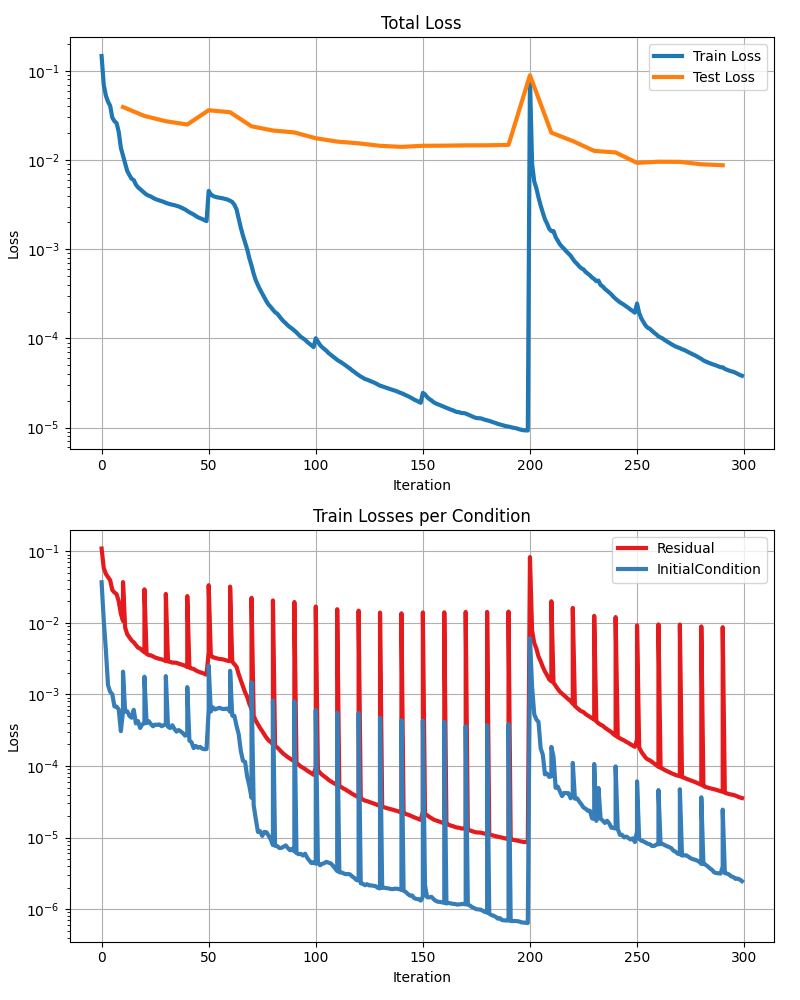

In [18]:
trainer.train()

pde.save("data/pde_pinn.pickle")
trainer.save("data/trainer_pinn.pickle")